In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


from matplotlib.ticker import MultipleLocator

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
# MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
# MTM_vicinity=[7,8,13,16,36,44,47,111,115,118]
MTM_vicinity=[7,8,44,]
# triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]
# triad_neigh_res=[58,62,63,65,67,69,70,80,81,82,93,94]
# triad_neigh_res=[62,65,69,80,81,82,93,94]
# triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]+triad_neigh_res

triad_neigh_res=[80,81,82,93,94]
triad_res=[60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]+triad_neigh_res

Triad_H3=[59,60,61,64,68]
Triad_L5=[i for i in range(71,80)]
Triad_L6=[i for i in range(83,93)]
hp_1=[19,23,32,34,51,53,108]
hp_2=[35,52,54,55,58,63,66,67,70]
pock=hp_1+hp_2

others=[i for i in range(1,120) if i not in MTM_all+triad_res+pock+triad_neigh_res+MTM_vicinity]

In [3]:
#PRE

WT_PRE_NC=pd.read_csv('../../../data/dihedrals/net_communication/preLC3B_OPLS/NET_COMM/preLC3B_OPLS_net_comm.csv',
                    index_col=0)
WT_PRE_full_np=WT_PRE_NC.to_numpy()+WT_PRE_NC.transpose().to_numpy()
WT_PRE_full_np=WT_PRE_full_np/np.max(WT_PRE_full_np)
WT_PRE_full_df=pd.DataFrame(WT_PRE_full_np)
WT_PRE_full_df

,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
0,0.000000,0.037449,0.054180,0.088415,0.072415,0.063390,0.047769,0.050867,0.064940,0.068183,...,0.084147,0.090716,0.105577,0.077425,0.058145,0.044077,0.043268,0.061654,0.085468,0.100003
1,0.037449,0.000000,0.063448,0.114216,0.107138,0.088392,0.057381,0.056279,0.090880,0.087667,...,0.118159,0.156247,0.155636,0.129314,0.131024,0.121750,0.173759,0.190056,0.197002,0.186936
2,0.054180,0.063448,0.000000,0.129456,0.126549,0.112462,0.075176,0.067404,0.113768,0.106728,...,0.135812,0.171661,0.175591,0.142269,0.165032,0.170706,0.228152,0.234700,0.226459,0.211996
3,0.088415,0.114216,0.129456,0.000000,0.165850,0.155395,0.112088,0.096856,0.143609,0.147702,...,0.158490,0.210468,0.210443,0.162286,0.154421,0.172407,0.234447,0.230663,0.223271,0.201924
4,0.072415,0.107138,0.126549,0.165850,0.000000,0.152301,0.109747,0.109617,0.150974,0.147346,...,0.148697,0.191222,0.188226,0.147293,0.122380,0.137013,0.166729,0.177247,0.181871,0.194105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.044077,0.121750,0.170706,0.172407,0.137013,0.113273,0.092602,0.085248,0.107570,0.112405,...,0.239715,0.316188,0.322249,0.280053,0.288048,0.000000,0.304865,0.303082,0.348379,0.362418
121,0.043268,0.173759,0.228152,0.234447,0.166729,0.143261,0.117633,0.093747,0.125556,0.144922,...,0.332419,0.392667,0.442880,0.351954,0.335819,0.304865,0.000000,0.347911,0.381566,0.393636
122,0.061654,0.190056,0.234700,0.230663,0.177247,0.155774,0.122113,0.107756,0.145233,0.155768,...,0.285660,0.383456,0.387637,0.332523,0.300633,0.303082,0.347911,0.000000,0.407782,0.422324
123,0.085468,0.197002,0.226459,0.223271,0.181871,0.180098,0.137167,0.133326,0.166566,0.173751,...,0.294835,0.431048,0.403556,0.363579,0.271912,0.348379,0.381566,0.407782,0.000000,0.362320


In [4]:
#UNB

WT_UNB_NC=pd.read_csv('../../../data/dihedrals/net_communication/LC3B_II_ER_protein/NET_COMM/LC3B_II_ER_protein_net_comm.csv',
                    index_col=0)
WT_UNB_full_np=WT_UNB_NC.to_numpy()+WT_UNB_NC.transpose().to_numpy()
WT_UNB_full_np=WT_UNB_full_np/np.max(WT_UNB_full_np)
WT_UNB_full_df=pd.DataFrame(WT_UNB_full_np)
WT_UNB_full_df

,0,1,2,3,4,5,6,7,8,9,...,109,110,111,112,113,114,115,116,117,118
0,0.000000,0.252592,0.236815,0.243170,0.194645,0.137060,0.109878,0.103053,0.137060,0.132555,...,0.072376,0.084087,0.099944,0.123600,0.158976,0.144991,0.202793,0.172997,0.212545,0.116410
1,0.252592,0.000000,0.331883,0.371719,0.327705,0.239599,0.170917,0.151606,0.239599,0.230593,...,0.076259,0.102260,0.137554,0.172455,0.245411,0.230283,0.382987,0.307054,0.408454,0.168614
2,0.236815,0.331883,0.000000,0.485563,0.494991,0.372946,0.271516,0.242909,0.372946,0.357831,...,0.090165,0.131910,0.211004,0.225733,0.272285,0.264781,0.343412,0.275390,0.349530,0.161337
3,0.243170,0.371719,0.485563,0.000000,0.612863,0.460740,0.333997,0.298732,0.460740,0.441635,...,0.101943,0.148564,0.242435,0.270025,0.333912,0.330500,0.426936,0.326236,0.425929,0.187439
4,0.194645,0.327705,0.494991,0.612863,0.000000,0.413453,0.323764,0.313370,0.413453,0.428419,...,0.118854,0.150255,0.247224,0.258760,0.321910,0.306356,0.331584,0.257482,0.313988,0.158640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,0.144991,0.230283,0.264781,0.330500,0.306356,0.197130,0.160809,0.160752,0.197130,0.194627,...,0.093097,0.165326,0.278677,0.275857,0.316883,0.000000,0.272667,0.232627,0.244741,0.156928
115,0.202793,0.382987,0.343412,0.426936,0.331584,0.183662,0.148995,0.145026,0.183662,0.181840,...,0.084006,0.134734,0.212131,0.226191,0.284492,0.272667,0.000000,0.274448,0.288977,0.193646
116,0.172997,0.307054,0.275390,0.326236,0.257482,0.149610,0.118211,0.115851,0.149610,0.137047,...,0.082830,0.117481,0.177624,0.178724,0.253477,0.232627,0.274448,0.000000,0.256976,0.180185
117,0.212545,0.408454,0.349530,0.425929,0.313988,0.172583,0.129076,0.128783,0.172583,0.160281,...,0.087614,0.106858,0.146539,0.169073,0.257896,0.244741,0.288977,0.256976,0.000000,0.178945


In [5]:
def rSubset(arr, r):
    return list(combinations(arr, r))

In [6]:
def net_comm_mat_slice(seg_i_name, seg_j_name, df_name):
    sliced_net_comm_=np.zeros((len(seg_i_name),len(seg_j_name)))
    for i in rSubset(seg_i_name, 2):
        i_ind=seg_i_name.index(i[0])
        j_ind=seg_j_name.index(i[1])
        sliced_net_comm_[i_ind][j_ind]=df_name[i[0]-1][i[1]-1]

    return sliced_net_comm_

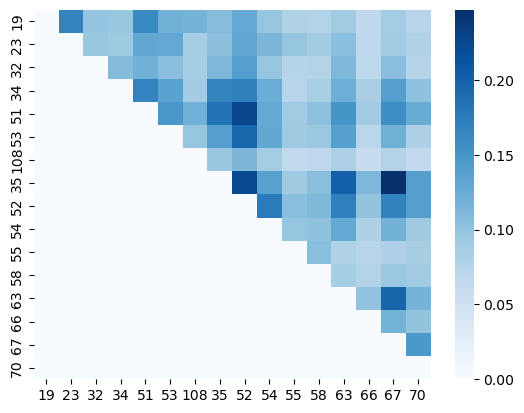

In [7]:
g=sns.heatmap(net_comm_mat_slice(pock, pock, WT_UNB_full_df),
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
plt.show()

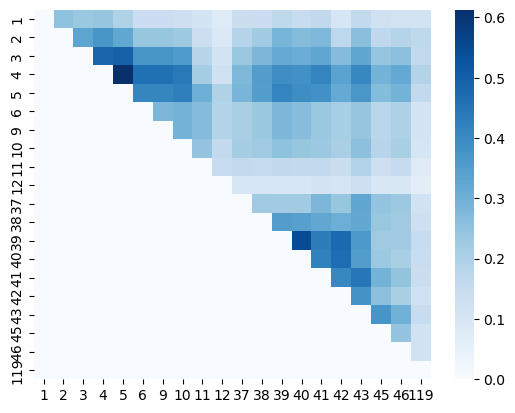

In [8]:
g=sns.heatmap(net_comm_mat_slice(MTM_core, MTM_core, WT_UNB_full_df),
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
g.set_yticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
plt.show()

In [9]:
intra_pock_total_coupling_pre=np.sum(net_comm_mat_slice(pock, pock, WT_PRE_full_df))
intra_mtm_total_coupling_pre=np.sum(net_comm_mat_slice(MTM_core, MTM_core, WT_PRE_full_df))

In [10]:
intra_pock_total_coupling_unb=np.sum(net_comm_mat_slice(pock, pock, WT_UNB_full_df))
intra_mtm_total_coupling_unb=np.sum(net_comm_mat_slice(MTM_core, MTM_core, WT_UNB_full_df))

In [11]:
print(intra_mtm_total_coupling_pre, intra_mtm_total_coupling_unb)

17.00207251918839 46.584665121529746


In [12]:
intra_mtm_total_coupling_pre-intra_mtm_total_coupling_unb

-29.582592602341357

In [13]:
print(intra_pock_total_coupling_pre, intra_pock_total_coupling_unb)

9.500634098661415 13.529113668451615


In [14]:
intra_pock_total_coupling_pre-intra_pock_total_coupling_unb

-4.0284795697902

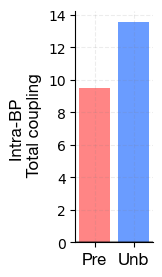

In [15]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(1,3))

ax.bar([0,1],[intra_pock_total_coupling_pre, intra_pock_total_coupling_unb], 
       color=["#FF7878","#5A91FF"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)


#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1], ['Pre', 'Unb'])
ax.set_xticklabels(['Pre', 'Unb'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

# ax.set_ylim([-15,5])
# ax.set_xlabel('States', fontdict=font)
ax.set_ylabel('Intra-BP \n Total coupling', fontdict=font)
plt.savefig("../../../plots/dihedrals/net_communication/bp_total_coupling.png", transparent=True, 
           bbox_inches="tight", 
           dpi=450)

In [16]:
# ls -ltr ../../../plots/dihedrals/net_communication/

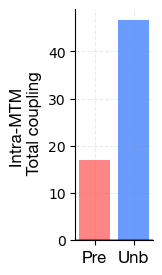

In [16]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(1,3))

ax.bar([0,1],[intra_mtm_total_coupling_pre, intra_mtm_total_coupling_unb], 
       color=["#FF7878","#5A91FF"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1], ['Pre', 'Unb'])
ax.set_xticklabels(['Pre', 'Unb'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

# ax.set_ylim([-15,5])
# ax.set_xlabel('States', fontdict=font)
ax.set_ylabel('Intra-MTM \n Total coupling', fontdict=font)
plt.savefig("../../../plots/dihedrals/net_communication/mtm_total_coupling.png", transparent=True, 
           bbox_inches="tight", 
           dpi=450)

In [17]:
def inter_net_comm_mat_slice(seg_i_name, seg_j_name, df_name):
    sliced_net_comm_=np.zeros((len(seg_i_name),len(seg_j_name)))
    for i in seg_i_name:
        for j in seg_j_name:
            i_ind=seg_i_name.index(i)
            j_ind=seg_j_name.index(j)
            sliced_net_comm_[i_ind][j_ind]=df_name[i-1][j-1]

    return sliced_net_comm_

In [18]:
allosteric_site_new_def=[60,61,64,68,73,78,79,80,81,82,87,88,89,90,91,92,93]

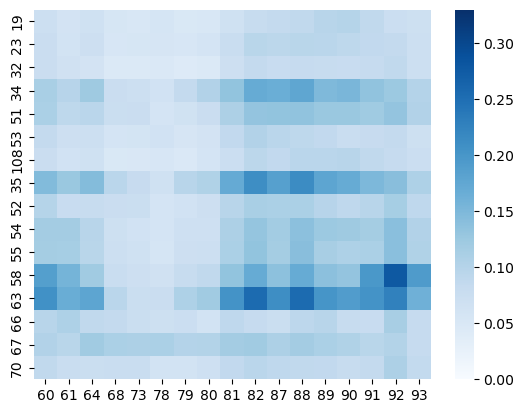

In [19]:

g=sns.heatmap(inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_PRE_full_df),
              cmap="Blues",vmin=0,vmax=0.33)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_xticks([i+0.5 for i in range(len(allosteric_site_new_def))],
            allosteric_site_new_def)
plt.show()

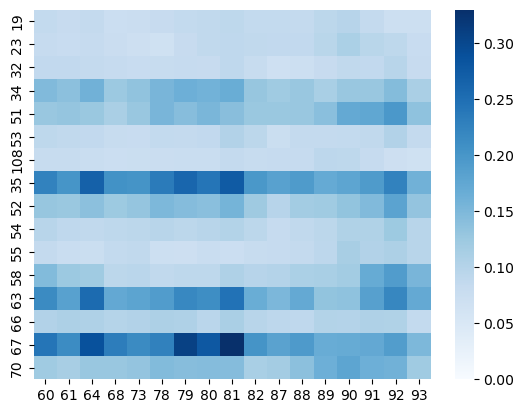

In [20]:

g=sns.heatmap(inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_UNB_full_df),
              cmap="Blues",vmin=0,vmax=0.33)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_xticks([i+0.5 for i in range(len(allosteric_site_new_def))],
            allosteric_site_new_def)
plt.show()

In [21]:
inter_bp_as_pre_mat=inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_PRE_full_df)
inter_bp_as_unb_mat=inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_UNB_full_df)



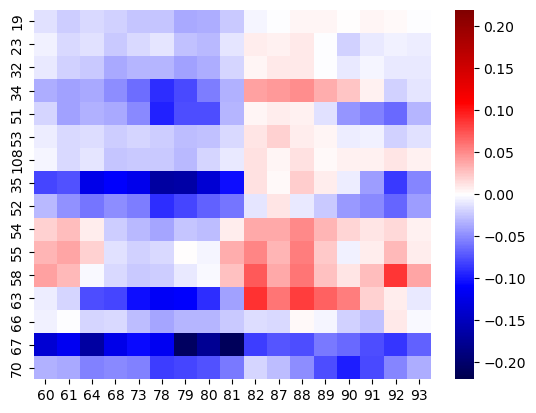

In [22]:

g=sns.heatmap(inter_bp_as_pre_mat-inter_bp_as_unb_mat,
              cmap="seismic", center=0, vmin=-0.22,vmax=0.22)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_xticks([i+0.5 for i in range(len(allosteric_site_new_def))],
            allosteric_site_new_def)
plt.show()

In [23]:
np.min(inter_bp_as_pre_mat-inter_bp_as_unb_mat),\
np.max(inter_bp_as_pre_mat-inter_bp_as_unb_mat)

(-0.2110879879819374, 0.08775362901033473)

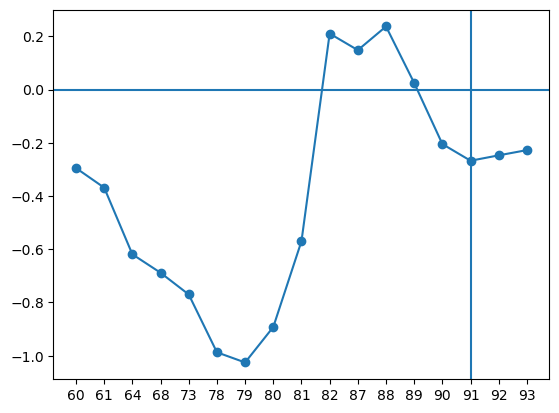

In [24]:
diff_as_bp=pd.DataFrame(inter_bp_as_pre_mat-inter_bp_as_unb_mat)
plt.plot([str(i) for i in allosteric_site_new_def],
         diff_as_bp.sum())
plt.scatter([str(i) for i in allosteric_site_new_def],
         diff_as_bp.sum())
plt.axhline(y=0)
plt.axvline(x=14)

In [26]:
inter_bp_as_pre=np.sum(inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_PRE_full_df))
inter_bp_as_unb=np.sum(inter_net_comm_mat_slice(pock, allosteric_site_new_def, WT_UNB_full_df))

In [35]:
inter_bp_as_pre-inter_bp_as_unb

-6.541551982680517

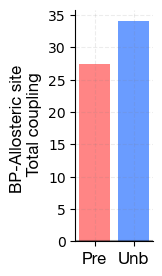

In [27]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(1,3))

ax.bar([0,1],[inter_bp_as_pre, inter_bp_as_unb], 
       color=["#FF7878","#5A91FF"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1], ['Pre', 'Unb'])
ax.set_xticklabels(['Pre', 'Unb'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

# ax.set_ylim([-15,5])
# ax.set_xlabel('States', fontdict=font)
ax.set_ylabel('BP-Allosteric site \n Total coupling', fontdict=font)
plt.savefig("../../../plots/dihedrals/net_communication/BP_ALLOSTERIC_SITE_total_coupling.png", transparent=True, 
           bbox_inches="tight", 
           dpi=450)

In [32]:
inter_bp_mtm_pre=np.sum(inter_net_comm_mat_slice(pock, MTM_core, WT_PRE_full_df))
inter_bp_mtm_unb=np.sum(inter_net_comm_mat_slice(pock, MTM_core, WT_UNB_full_df))

In [34]:
inter_bp_mtm_pre-inter_bp_mtm_unb

-13.520491547319697

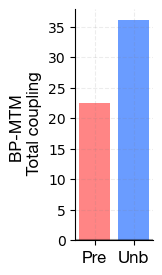

In [33]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(1,3))

ax.bar([0,1],[inter_bp_mtm_pre, inter_bp_mtm_unb], 
       color=["#FF7878","#5A91FF"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1], ['Pre', 'Unb'])
ax.set_xticklabels(['Pre', 'Unb'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

# ax.set_ylim([-15,5])
# ax.set_xlabel('States', fontdict=font)
ax.set_ylabel('BP-MTM \n Total coupling', fontdict=font)
plt.savefig("../../../plots/dihedrals/net_communication/BP_MTM_total_coupling.png", transparent=True, 
           bbox_inches="tight", 
           dpi=450)

In [29]:
inter_bp_l6_pre_mat=inter_net_comm_mat_slice(pock,[i for i in range(83,95)] , WT_PRE_full_df)
inter_bp_l6_unb_mat=inter_net_comm_mat_slice(pock, [i for i in range(83,95)], WT_UNB_full_df)



In [30]:
np.min(inter_bp_l6_pre_mat-inter_bp_l6_unb_mat),\
np.max(inter_bp_l6_pre_mat-inter_bp_l6_unb_mat)

(-0.09732672349451407, 0.15503232950708123)

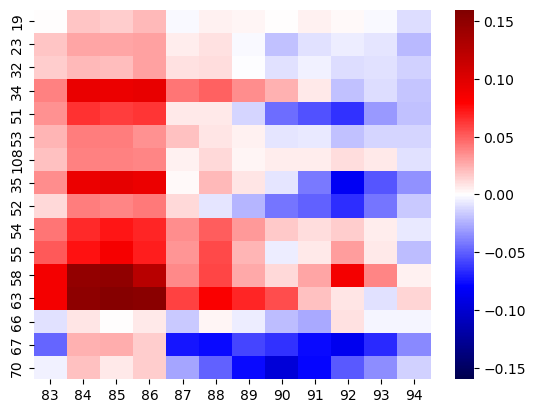

In [31]:

g=sns.heatmap(inter_bp_l6_pre_mat-inter_bp_l6_unb_mat,
              cmap="seismic", center=0, vmin=-0.16,vmax=0.16)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_xticks([i+0.5 for i in range(len([i for i in range(83,95)]))],
            [i for i in range(83,95)])
plt.show()

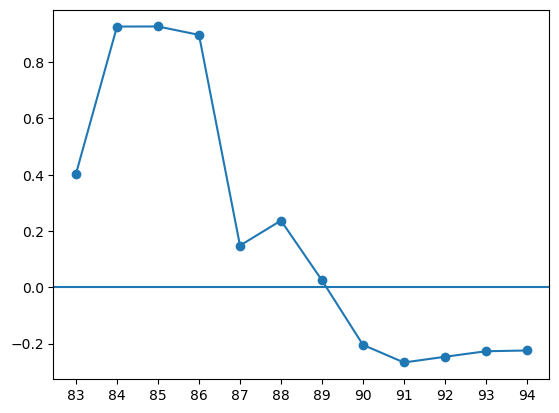

In [32]:
diff_as_bp=pd.DataFrame(inter_bp_l6_pre_mat-inter_bp_l6_unb_mat)
plt.plot([str(i) for i in [i for i in range(83,95)]],
         diff_as_bp.sum())
plt.scatter([str(i) for i in [i for i in range(83,95)]],
         diff_as_bp.sum())
plt.axhline(y=0)
# plt.axvline(x=14)

In [33]:
inter_bp_triad_reg_pre_mat=inter_net_comm_mat_slice(pock,triad_res , WT_PRE_full_df)
inter_bp_triad_reg_unb_mat=inter_net_comm_mat_slice(pock, triad_res, WT_UNB_full_df)



In [34]:
np.sum(inter_bp_triad_reg_pre_mat)

43.11302603811978

In [35]:
np.sum(inter_bp_triad_reg_unb_mat)

48.73866680814994

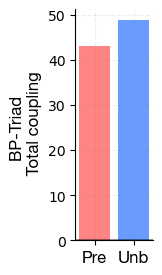

In [36]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

fig, ax = plt.subplots(figsize=(1,3))

ax.bar([0,1],[np.sum(inter_bp_triad_reg_pre_mat), np.sum(inter_bp_triad_reg_unb_mat)], 
       color=["#FF7878","#5A91FF"],
      alpha=0.9)
ax.axhline(y=0, color="black",alpha=0.4)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)



#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1], ['Pre', 'Unb'])
ax.set_xticklabels(['Pre', 'Unb'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)

# ax.set_ylim([-15,5])
# ax.set_xlabel('States', fontdict=font)
ax.set_ylabel('BP-Triad \n Total coupling', fontdict=font)
plt.savefig("../../../plots/dihedrals/net_communication/BP_triad_total_coupling.png", transparent=True, 
           bbox_inches="tight", 
           dpi=450)